# Лабораторна робота №8. Структура даних граф. Алгоритми на графах

##### AUTHOR

© Kremliakov Hlib

### Мета

Засвоїти представлення структури даних граф та основні 
алгоритми роботи з ними засобами Python.

## Хід роботи

### Завдання

Реалізувати контрольні приклади.

– Для варіанту, заданого викладачем, задати і візуалізувати граф за 
допомогою коду, наведеного у цій роботі. 

– Для свого варіанту реалізувати всі алгоритми, згідно з прикладами, 
наведеними вище. 

## Виконання

In [13]:
!pip install networkx matplotlib

### Створення класів Vertex і Graph

In [1]:
class Vertex:
    def __init__(self, key):
        self.id = key
        self.connectedTo = {}

    def addNeighbor(self, nbr, weight=0):
        self.connectedTo[nbr] = weight

    def __str__(self):
        return str(self.id) + ' connectedTo: ' + str([x.id for x in self.connectedTo])

    def getConnections(self):
        return self.connectedTo.keys()

    def getId(self):
        return self.id

    def getWeight(self, nbr):
        return self.connectedTo[nbr]


class Graph:
    def __init__(self):
        self.vertList = {}
        self.numVertices = 0

    def addVertex(self, key):
        self.numVertices += 1
        newVertex = Vertex(key)
        self.vertList[key] = newVertex
        return newVertex

    def getVertex(self, n):
        if n in self.vertList:
            return self.vertList[n]
        return None

    def __contains__(self, n):
        return n in self.vertList

    def addEdge(self, f, t, cost=0):
        if f not in self.vertList:
            self.addVertex(f)

        if t not in self.vertList:
            self.addVertex(t)

        self.vertList[f].addNeighbor(self.vertList[t], cost)

    def getVertices(self):
        return self.vertList.keys()

    def __iter__(self):
        return iter(self.vertList.values())

### Створення та заповнення графа

In [2]:
g = Graph()

g.addEdge('A', 'B', 4)
g.addEdge('A', 'C', 2)
g.addEdge('B', 'D', 5)
g.addEdge('C', 'D', 8)
g.addEdge('C', 'E', 10)
g.addEdge('D', 'E', 2)

for v in g:
    for w in v.getConnections():
        print(f"{v.getId()} -> {w.getId()} , weight = {v.getWeight(w)}")

A -> B , weight = 4
A -> C , weight = 2
B -> D , weight = 5
C -> D , weight = 8
C -> E , weight = 10
D -> E , weight = 2


### Візуалізація графа

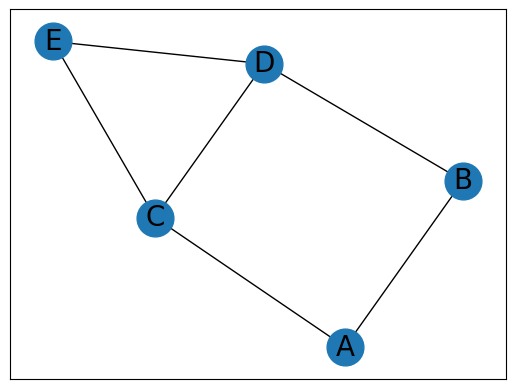

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_nodes_from(['A', 'B', 'C', 'D', 'E'])

G.add_edges_from([
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'D'),
    ('C', 'D'),
    ('C', 'E'),
    ('D', 'E')
])

pos = nx.spring_layout(G)

nx.draw_networkx_nodes(G, pos, node_size=700)
nx.draw_networkx_labels(G, pos, font_size=20)
nx.draw_networkx_edges(G, pos)

plt.show()

### Алгоритм DFS (пошук у глибину)

In [14]:
def dfs(graph, start, visited=None):

    if visited is None:
        visited = set()

    visited.add(start)

    for next in set(graph.adj[start]) - visited:
        dfs(graph, next, visited)

    return visited


print(dfs(G, 'A'))

{'E', 'A', 'D', 'C', 'B'}


### Пошук усіх шляхів DFS

In [15]:
def dfs_paths(graph, start, goal, path=None):

    if path is None:
        path = [start]

    if start == goal:
        yield path

    for next in set(graph.adj[start]) - set(path):
        yield from dfs_paths(graph, next, goal, path + [next])


print(list(dfs_paths(G, 'A', 'E')))

[['A', 'C', 'E'], ['A', 'C', 'D', 'E'], ['A', 'B', 'D', 'C', 'E'], ['A', 'B', 'D', 'E']]


### Алгоритм BFS (пошук у ширину)

In [16]:
def bfs_paths(graph, start, goal):

    queue = [(start, [start])]

    while queue:

        (vertex, path) = queue.pop(0)

        for next in set(graph.adj[vertex]) - set(path):

            if next == goal:
                yield path + [next]

            else:
                queue.append((next, path + [next]))


print(list(bfs_paths(G, 'A', 'E')))

[['A', 'C', 'E'], ['A', 'C', 'D', 'E'], ['A', 'B', 'D', 'E'], ['A', 'B', 'D', 'C', 'E']]


### Алгоритм Дейкстри

In [17]:
import networkx as nx

DG = nx.DiGraph()

DG.add_weighted_edges_from([
    ('A', 'B', 4),
    ('A', 'C', 2),
    ('B', 'D', 5),
    ('C', 'D', 8),
    ('C', 'E', 10),
    ('D', 'E', 2)
])

length, path = nx.single_source_dijkstra(DG, 'A')

print("Найкоротші відстані:")
print(length)

print("Шляхи:")
print(path)

Найкоротші відстані:
{'A': 0, 'C': 2, 'B': 4, 'D': 9, 'E': 11}
Шляхи:
{'A': ['A'], 'C': ['A', 'C'], 'B': ['A', 'B'], 'D': ['A', 'B', 'D'], 'E': ['A', 'B', 'D', 'E']}


### Алгоритм Беллмана-Форда

In [18]:
length = nx.single_source_bellman_ford_path_length(DG, 'A')

print(length)

{'A': 0, 'B': 4, 'C': 2, 'D': 9, 'E': 11}


## Висновок

У ході лабораторної роботи було досліджено структуру даних граф та методи роботи з нею у Python. Було реалізовано класи Vertex і Graph, виконано візуалізацію графа та реалізовано алгоритми DFS, BFS, Дейкстри і Беллмана-Форда. Також було отримано практичні навички роботи з бібліотекою NetworkX.

## Контрольні питання

### 1. Що таке граф у термінах теорії графів?

Граф — це структура даних, яка складається з множини вершин і ребер між ними.
Графи використовуються для моделювання доріг, соціальних мереж, комп’ютерних мереж та маршрутів.

### 2. Які основні види графів існують?

Існують:

- орієнтовані;
- неорієнтовані;
- зважені;
- незважені графи.

В орієнтованому графі ребра мають напрямок, а в неорієнтованому — ні.

### 3. Як можна представити граф у пам’яті комп'ютера?

Граф можна представити:

- матрицею суміжності;
- списком суміжності.

Матриця суміжності зручна для щільних графів, а список суміжності — для розріджених.

### 4. Як працює алгоритм BFS?

BFS обходить граф по рівнях, використовуючи чергу.
Спочатку відвідуються всі сусіди вершини, потім сусіди сусідів.

Використовується для:

- пошуку найкоротшого шляху;
- аналізу мереж;
- навігації.

### 5. Що таке DFS і чим він відрізняється від BFS?

DFS — це пошук у глибину. Алгоритм проходить максимально глибоко по графу перед поверненням назад.

DFS використовує рекурсію або стек, а BFS — чергу.

DFS застосовується для:

- пошуку циклів;
- обходу графів;
- топологічного сортування.

### 6. Опишіть алгоритм Дейкстри

Алгоритм Дейкстри знаходить найкоротші шляхи від однієї вершини до всіх інших.

Умова роботи алгоритму:

- усі ваги ребер повинні бути невід’ємними.